# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Adelia Eka Agustin
- **Email:** adeliaekaagustin@gmail.com
- **ID Dicoding:** CDCC208D6X1786

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana variasi kondisi cuaca dan temperatur memengaruhi perubahan jumlah peminjaman sepeda harian, serta pada kondisi apa terjadi lonjakan penggunaan tertinggi selama tahun 2011-2012?
- **Pertanyaan 2:** Bagaimana perbedaan pola penggunaan sepeda antara hari kerja dan akhir pekan pada setiap musim, serta kapan waktu dengan permintaan tertinggi selama periode 2011-2012?

## Import Semua Packages/Library yang Digunakan

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load Dataset

In [17]:
import zipfile

with zipfile.ZipFile('Bike-sharing-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall()

day_df = pd.read_csv('day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
Dataset berisi data peminjaman sepeda harian dengan berbagai variabel informasi seperti kondisi cuaca, musim, temperatur dan jumlah peminjaman.

### Assessing Data

#### Identifying Problems

In [18]:
day_df.info()
day_df.isna().sum()
day_df.duplicated().sum()
day_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight (Permasalahan Data):**
- Kolom dteday masih bertipe object dan belum dalam format tanggal (datetime)
- Variabel kategori seperti season dan weathersit masih dalam bentuk angka sehingga tidak diketahui informasi apa yang disampaikan
- Tidak ditemukannya missing value dan data yang duplikat

**Steps to Take:**
- Ubah tipe data dteday menjadi datetime
- Ubah kode kategori mejadi label yang lebih mudah dipahami

### Cleaning Data

#### Fixing Problem

In [19]:
#ubah tipe data
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

#beri label pada data kategorik
season_map = {1:'Spring',2:'Summer',3:'Fall',4:'Winter'}
weather_map = {1:'Clear',2:'Mist',3:'Light Snow',4:'Heavy Rain'}

day_df['season'] = day_df['season'].map(season_map)
day_df['weathersit'] = day_df['weathersit'].map(weather_map)

**Insight:**
Data telah dibersihkan dan variabel kategori sudah bisa lebih mudah dipahami sehingga siap untuk dianalisis lebih lanjut

## Exploratory Data Analysis (EDA)

### Statistik Deskriptif

In [20]:
day_df.describe()

,instant,dteday,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,0.500684,6.519836,0.028728,2.997264,0.683995,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,0.000000,4.000000,0.000000,1.000000,0.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,1.000000,7.000000,0.000000,3.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,1.000000,10.000000,0.000000,5.000000,1.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,1.000000,12.000000,1.000000,6.000000,1.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,0.500342,3.451913,0.167155,2.004787,0.465233,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


### Analisis Cuaca dan Temperatur

In [23]:
day_df.groupby('weathersit')['cnt'].mean().sort_values(ascending=False)

,cnt
weathersit,
Clear,4876.786177
Mist,4035.862348
Light Snow,1803.285714


In [24]:
day_df[['temp','cnt']].corr()

,temp,cnt
temp,1.000000,0.627494
cnt,0.627494,1.000000


**Insight:**
- Jumlah peminjaman sepeda paling tinggi terjadi pada kondisi cuaca cerah.
- Ketika kondisi cuaca memburuk, jumlah peminjaman menurun secara cukup signifikan.
- Temperatur memiliki hubungan positif dengan jumlah peminjaman, artinya semakin nyaman suhu, semakin tinggi penggunaan sepeda.

### Analisis Musim dan Hari

In [25]:
day_df.groupby(['season','workingday'])['cnt'].mean()

season  workingday
Fall    0             5474.666667
        1             5718.114504
Spring  0             2257.098361
        1             2780.541667
Summer  0             5142.428571
        1             4926.664062
Winter  0             4606.210526
        1             4785.611570
Name: cnt, dtype: float64

In [15]:
day_df['month'] = day_df['dteday'].dt.month
day_df.groupby('month')['cnt'].mean()

,cnt
month,
1,2176.338710
2,2655.298246
3,3692.258065
4,4484.900000
5,5349.774194
6,5772.366667
7,5563.677419
8,5664.419355
9,5766.516667


**Insight:**
- Penggunaan sepeda cenderung lebih tinggi pada akhir pekan dibandingkan hari kerja.
- Musim Fall dan Summer menunjukkan tingkat penggunaan tertinggi.
- Terdapat pola bulanan yang menunjukkan adanya periode tertentu dengan permintaan lebih tinggi.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

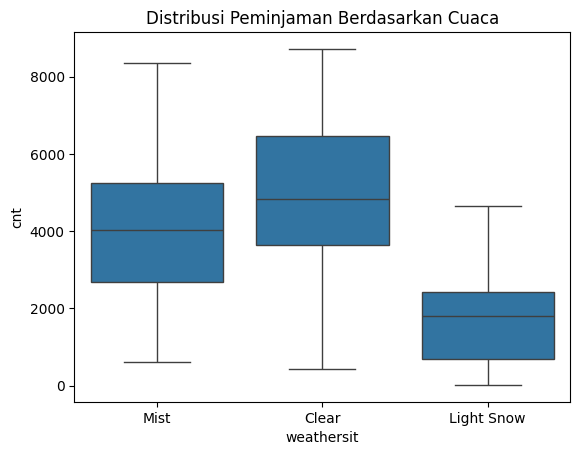

In [26]:
sns.boxplot(data=day_df, x='weathersit', y='cnt')
plt.title('Distribusi Peminjaman Berdasarkan Cuaca')
plt.show()

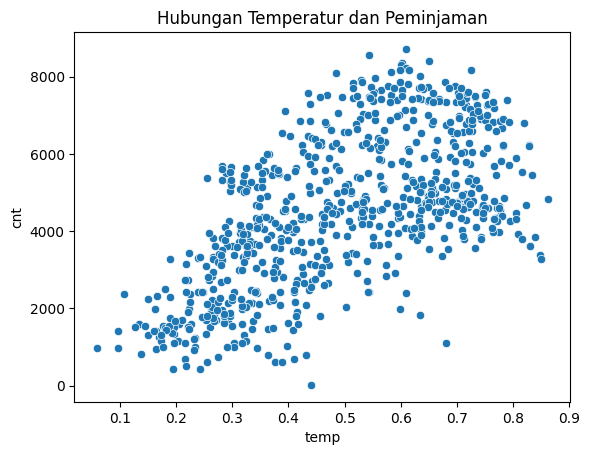

In [27]:
sns.scatterplot(data=day_df, x='temp', y='cnt')
plt.title('Hubungan Temperatur dan Peminjaman')
plt.show()

**Insight:**
Cuaca cerah tidak hanya memiliki rata-rata tinggi, tetapi juga distribusi yang lebih stabil. Grafik menunjukkan bahwa peningkatan temperatur diikuti dengan peningkatan jumlah peminjaman.

### Pertanyaan 2:

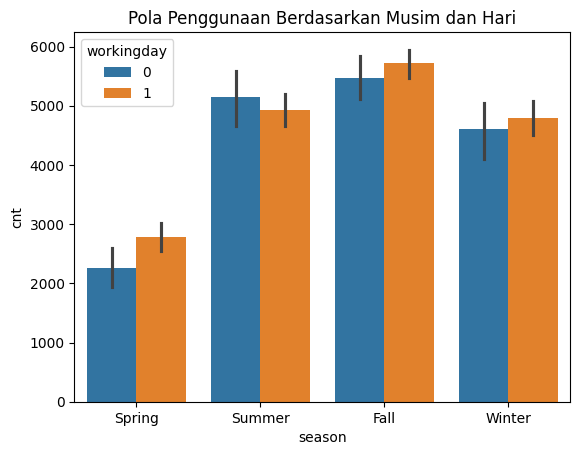

In [28]:
sns.barplot(data=day_df, x='season', y='cnt', hue='workingday')
plt.title('Pola Penggunaan Berdasarkan Musim dan Hari')
plt.show()

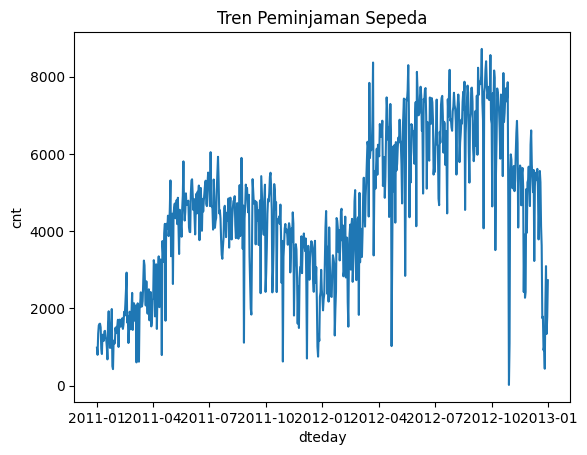

In [29]:
sns.lineplot(data=day_df, x='dteday', y='cnt')
plt.title('Tren Peminjaman Sepeda')
plt.show()

**Insight:**
Pada hampir semua musim, akhir pekan menunjukkan penggunaan yang lebih tinggi. Grafik tren menunjukkan adanya pola naik turun yang berkaitan dengan musim dan waktu.

## Analisis Lanjutan (Teknik Binning)

In [31]:
day_df['usage_level'] = pd.cut(
    day_df['cnt'],
    bins=[0,3000,6000,9000],
    labels=['Rendah','Sedang','Tinggi']
)

day_df['usage_level'].value_counts()

,count
usage_level,
Sedang,379
Tinggi,180
Rendah,172


**Insight:**
Analisis lanjutan ini menggunakan teknik binning untuk mengelompokkan data berdasarkan tingkat penggunaan sepeda. Metode ini termasuk dalam clustering sederhana tanpa menggunakan algoritma machine learning. Tujuannya adalah untuk melihat bagaimana distribusi tingkat penggunaan sepeda dalam dataset secara lebih terstruktur.

Berdasarkan hasil pengelompokan, sebagian besar data berada pada kategori penggunaan sedang, sementara kategori tinggi hanya muncul pada kondisi tertentu.
Hal ini menunjukkan bahwa lonjakan penggunaan sepeda tidak terjadi setiap hari, melainkan hanya pada kondisi tertentu seperti cuaca yang mendukung dan waktu tertentu.
Dengan kata lain, permintaan sepeda cenderung stabil pada level menengah, tetapi dapat meningkat signifikan ketika kondisi optimal terpenuhi. Hasil analisis lanjutan ini mendukung temuan sebelumnya bahwa penggunaan sepeda dipengaruhi oleh kondisi tertentu, dan tidak terjadi secara merata pada setiap waktu.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Variasi kondisi cuaca dan temperatur memiliki pengaruh yang jelas terhadap jumlah peminjaman sepeda. Peminjaman tertinggi terjadi pada kondisi cuaca cerah dengan temperatur yang lebih hangat, sedangkan kondisi cuaca buruk menyebabkan penurunan jumlah pengguna.
- **Conclusion pertanyaan 2:** Terdapat perbedaan pola penggunaan antara hari kerja dan akhir pekan, di mana akhir pekan menunjukkan tingkat penggunaan yang lebih tinggi. Selain itu, musim Fall dan Summer serta beberapa periode tertentu dalam satu tahun menjadi waktu dengan permintaan tertinggi.

**Rekomendasi Action Item:**
- Menyesuaikan ketersediaan sepeda pada kondisi cuaca cerah dan temperatur yang mendukung, karena pada kondisi tersebut permintaan cenderung meningkat.
- Mengoptimalkan distribusi sepeda pada akhir pekan serta musim dengan permintaan tinggi seperti Fall dan Summer untuk meningkatkan efisiensi layanan.